# Environment

In [1]:
import sys
from pathlib import Path
import sqlite3
module_path = Path("../01_Functions_classes_and_variables").resolve()
sys.path.append(str(module_path))

from simulation_data_functions import *
from data_exploration_functions import *
from data_operations_functions import *

import matplotlib.pyplot as plt
from spreg import ML_Lag
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from econml.dml import CausalForestDML

from esda.moran import Moran


from sklearn.ensemble import RandomForestRegressor
from causalml.inference.meta import BaseSRegressor
from econml.dml import DML, LinearDML, SparseLinearDML, CausalForestDML
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import PolynomialFeatures

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor

from sklearn.metrics import r2_score

In [2]:
repo_path_wndws = Path("../").resolve()
repo_path_unix = repo_path_wndws.as_posix() 
repo_path_r_string = repo_path_unix.replace("/", '\\')

# Data

In [3]:
dict_of_combs = {

    'a1': [6,10,1],

    'a2': [6,10,1.5],
    
    'a3': [6,10,2],
    
    'a4': [6,10,3.5],
    
    'a5': [6,10,4],

     'a6': [6,10,4.5],

    'a7': [6,10,5],
    
    'a8': [6,10,5.5],
    
    'a9': [6,10,6],
    
    'a10': [6,10,6.5],


    'b1': [7,11,1],

    'b2': [7,11,1.5],
    
    'b3': [7,11,2],
    
    'b4': [7,11,3.5],
    
    'b5': [7,11,4],

     'b6': [7,11,4.5],

    'b7': [7,11,5],
    
    'b8': [7,11,5.5],
    
    'b9': [7,11,6],
    
    'b10': [7,11,6.5],


    'c1': [8,12,1],

    'c2': [8,12,1.5],
    
    'c3': [8,12,2],
    
    'c4': [8,12,3.5],
    
    'c5': [8,12,4],

     'c6': [8,12,4.5],

    'c7': [8,12,5],
    
    'c8': [8,12,5.5],
    
    'c9': [8,12,6],
    
    'c10': [8,12,6.5],

        'd1': [9,13,1],

    'd2': [9,13,1.5],
    
    'd3': [9,13,2],
    
    'd4': [9,13,3.5],
    
    'd5': [9,13,4],

     'd6': [9,13,4.5],

    'd7': [9,13,5],
    
    'd8': [9,13,5.5],
    
    'd9': [9,13,6],
    
    'd10': [9,13,6.5],
    
}


In [8]:
connection_link_var = repo_path_r_string + r'\03_simulated_data\simulated_data_effect_size.sqlite'
dict_of_gdfs = {}
for i in dict_of_combs:

        df = import_non_spatial_data_frame(
                connection_link = connection_link_var,
                df_to_return_name =  i
        )
        gdf = gpd.GeoDataFrame(
                df,
                geometry=gpd.points_from_xy(df["x"], df["y"]),
                crs="EPSG:3857"
                )
        
        dict_of_gdfs[i] = gdf

In [9]:
dict_of_gdfs.keys()

dict_keys(['a1', 'a2', 'a3', 'a4', 'a5', 'a6', 'a7', 'a8', 'a9', 'a10', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6', 'b7', 'b8', 'b9', 'b10', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9', 'c10', 'd1', 'd2', 'd3', 'd4', 'd5', 'd6', 'd7', 'd8', 'd9', 'd10'])

<Axes: >

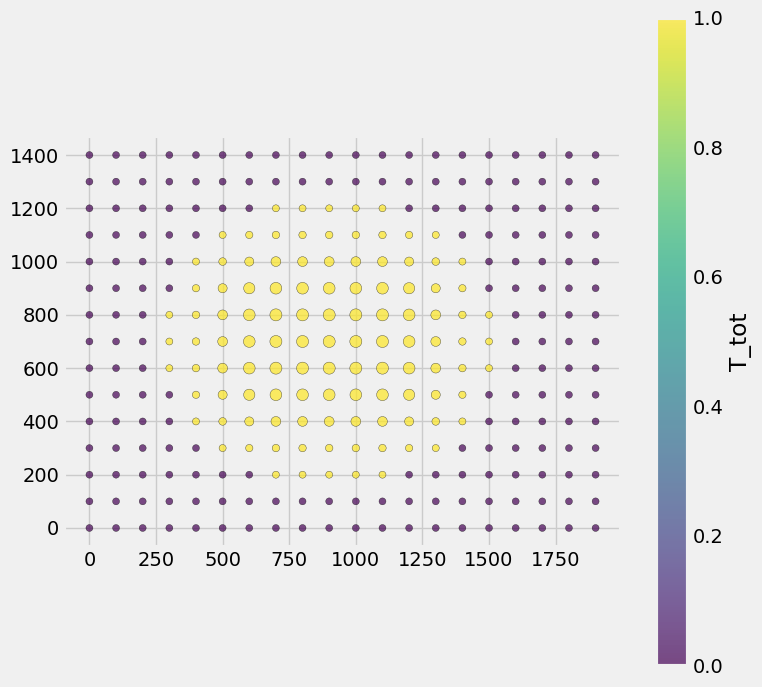

In [10]:

temp_gdf = dict_of_gdfs['b4'].copy()
temp_gdf['spill2'] = temp_gdf['spill'] + 0.5
plot_gdf_points(temp_gdf, size_col='spill2',
    color_col='T_tot')

# Function to parralize

In [4]:
from joblib import Parallel, delayed

In [5]:
def process_single_key(i):

    # =========================================================
    # 0. Data preparation
    # =========================================================

    temp_gdf = dict_of_gdfs[i].copy()

    df_effectbase = pd.DataFrame({
        'ring': [
            'treated_inner_ring',
            'treated_outer_ring1',
            'treated_outer_ring2',
            'treated_outer_ring3',
            'treated_outer_ring4'
        ],
        'true_effect': [
            temp_gdf[temp_gdf['T'] == 1]['tau'].mean(),
            temp_gdf[temp_gdf['ODR_1'] == 1]['tau'].mean(),
            temp_gdf[temp_gdf['ODR_2'] == 1]['tau'].mean(),
            temp_gdf[temp_gdf['ODR_3'] == 1]['tau'].mean(),
            temp_gdf[temp_gdf['ODR_4'] == 1]['tau'].mean(),
        ],
    })

    X = temp_gdf[["C1","C2"]].values

    T_M = temp_gdf['T_tot_cat'].astype(str).values

    Y = temp_gdf['Y_dep_var_ns'].values

    T_mult = temp_gdf[
        ['T', 'ODR_1','ODR_2','ODR_3','ODR_4']
    ].to_numpy()

    T_D_id = temp_gdf[
        ['T', 'Cont_T_N']
    ].to_numpy()

    Xdf_did = temp_gdf[
        ['T', 'ODR_1','ODR_2','ODR_3','ODR_4',"C1","C2"]
    ]

    X_did = sm.add_constant(Xdf_did)

    y_did = temp_gdf['Y_dep_var_ns']

    # =========================================================
    # 1. Multi-treatment S-Learner
    # =========================================================

    mS_learn = BaseSRegressor(
        RandomForestRegressor(
            n_estimators=160,
            max_depth=10,
            random_state=42,
            n_jobs=1
        ),
        control_name='control'
    )

    ite_mS_learn = mS_learn.fit_predict(X, T_M, Y)

    ITE_df_mSlearn = pd.DataFrame(ite_mS_learn).rename(columns={
        0:'treated_inner_ring',
        1:'treated_outer_ring1',
        2:'treated_outer_ring2',
        3:'treated_outer_ring3',
        4:'treated_outer_ring4',
    })

    ITE_df_mSlearn['treated'] = T_M

    df_multi_treatment_effects_Slearn = make_treatment_effects_df(
        ITE_df_mSlearn,
        [
            'treated_inner_ring',
            'treated_outer_ring1',
            'treated_outer_ring2',
            'treated_outer_ring3',
            'treated_outer_ring4',
        ],
        'mSlearn',
        treated_col='treated'
    )

    df_multi_effect_pre1 = df_effectbase.merge(
        df_multi_treatment_effects_Slearn,
        on='ring',
        how='left'
    )

    # =========================================================
    # 2. Multi-treatment Causal Forest
    # =========================================================

    mCF = CausalForestDML(
        model_y=RandomForestRegressor(
            n_estimators=100,
            max_depth=3,
            min_samples_leaf=20,
            n_jobs=1
        ),
        model_t=MultiOutputRegressor(
            RandomForestRegressor(
                n_estimators=100,
                max_depth=3,
                min_samples_leaf=20,
                n_jobs=1
            )
        ),
        cv=None,
        criterion='mse',
        n_estimators=1000,
        min_samples_leaf=10,
        min_impurity_decrease=0.001,
        random_state=123
    )

    mCF.tune(Y, T_mult, X=X)
    mCF.fit(Y, T_mult, X=X)

    mCF_pred = mCF.const_marginal_effect(X)

    ITE_mCF = pd.DataFrame(mCF_pred).rename(
        columns=replacing_dict_0_ring
    )

    ITE_mCF['treated'] = T_M

    df_multi_treatment_effects_mCF = make_treatment_effects_df(
        ITE_mCF,
        [
            'treated_inner_ring',
            'treated_outer_ring1',
            'treated_outer_ring2',
            'treated_outer_ring3',
            'treated_outer_ring4'
        ],
        'mCF',
        treated_col='treated'
    )

    df_multi_effect_pre2 = df_multi_effect_pre1.merge(
        df_multi_treatment_effects_mCF,
        on='ring',
        how='left'
    )

    # =========================================================
    # 3. Double-treatment Causal Forest
    # =========================================================

    dCF = CausalForestDML(
        model_y=RandomForestRegressor(
            n_estimators=100,
            max_depth=3,
            min_samples_leaf=20,
            n_jobs=1
        ),
        model_t=MultiOutputRegressor(
            RandomForestRegressor(
                n_estimators=100,
                max_depth=3,
                min_samples_leaf=20,
                n_jobs=1
            )
        ),
        cv=None,
        criterion='mse',
        n_estimators=1000,
        min_samples_leaf=10,
        min_impurity_decrease=0.001,
        random_state=123
    )

    dCF.tune(Y, T_D_id, X=X)
    dCF.fit(Y, T_D_id, X=X)

    dCF_pred = dCF.const_marginal_effect(X)

    ITE_dCF = pd.DataFrame(dCF_pred).rename(columns={
        0:'treated_inner_ring',
        1:'treated_outer_rings',
    })

    ITE_dCF['treated'] = T_M

    ITE_dCF['treated_outer_ring1'] = ITE_dCF['treated_outer_rings']
    ITE_dCF['treated_outer_ring2'] = ITE_dCF['treated_outer_rings']/2
    ITE_dCF['treated_outer_ring3'] = ITE_dCF['treated_outer_rings']/3
    ITE_dCF['treated_outer_ring4'] = ITE_dCF['treated_outer_rings']/4

    df_multi_treatment_effects_dCF = make_treatment_effects_df(
        ITE_dCF,
        [
            'treated_inner_ring',
            'treated_outer_ring1',
            'treated_outer_ring2',
            'treated_outer_ring3',
            'treated_outer_ring4'
        ],
        'dCF',
        treated_col='treated'
    )

    df_multi_effect_pre3 = df_multi_effect_pre2.merge(
        df_multi_treatment_effects_dCF,
        on='ring',
        how='left'
    )

    # =========================================================
    # 4. Difference in Differences
    # =========================================================

    model_did = sm.OLS(y_did, X_did)
    results_did = model_did.fit()

    coef_df_did = pd.DataFrame({
        "ring": results_did.params.index,
        "att_mDiD": results_did.params.values,
        "se_mDiD": results_did.bse.values
    })

    coef_df_did = coef_df_did[
        coef_df_did['ring'].isin([
            'T', 'ODR_1', 'ODR_2', 'ODR_3', 'ODR_4'
        ])
    ].copy()

    coef_df_did['ring'] = coef_df_did['ring'].replace(
        replacing_dict_odr_ring
    )

    df_multi_effect_temp = df_multi_effect_pre3.merge(
        coef_df_did,
        on='ring',
        how='left'
    )

    df_multi_effect_temp['effect_size'] = (
        1 / dict_of_combs[i][2] * 100
    )

    df_multi_effect_temp = df_multi_effect_temp[
        [
            'effect_size',
            'ring',
            'true_effect',
            'att_mSlearn',
            'se_mSlearn',
            'att_mCF',
            'se_mCF',
            'att_dCF',
            'se_dCF',
            'att_mDiD',
            'se_mDiD'
        ]
    ]

    return df_multi_effect_temp

# Modelling causal inference

In [13]:
len(dict_of_gdfs.keys())

40

In [6]:
replacing_dict_0_ring = {0:'treated_inner_ring', 1:'treated_outer_ring1', 
                                             2:'treated_outer_ring2',
                                             3:'treated_outer_ring3',
                                             4:'treated_outer_ring4'
                                             }

replacing_dict_odr_ring = {'T':'treated_inner_ring', 
                                                                        'ODR_1':'treated_outer_ring1', 
                                                                        'ODR_2':'treated_outer_ring2',
                                                                        'ODR_3':'treated_outer_ring3',
                                                                        'ODR_4':'treated_outer_ring4'
                                                                          }

In [14]:
list_of_output_dfs = Parallel(
    n_jobs=-1,
    backend="loky",
    verbose=10
)(
    delayed(process_single_key)(i)
    for i in dict_of_gdfs.keys()
)

df_results = pd.concat(list_of_output_dfs, ignore_index=True)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   46.4s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:   47.8s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done  22 out of  40 | elapsed:  1.5min remaining:  1.3min
[Parallel(n_jobs=-1)]: Done  27 out of  40 | elapsed:  2.1min remaining:  1.0min
[Parallel(n_jobs=-1)]: Done  32 out of  40 | elapsed:  2.2min remaining:   32.8s
[Parallel(n_jobs=-1)]: Done  37 out of  40 | elapsed:  2.5min remaining:   12.3s
[Parallel(n_jobs=-1)]: Done  40 out of  40 | elapsed:  2.5min finished


In [17]:
dict_of_gdfs['a1']

,unit_id,x,y,T,T_tot,T_tot_cat,T_tot_cat_underestim,ODR_1,ODR_2,ODR_3,ODR_4,Cont_T_N,C1,C2,tau,spill,Y_dep_var,Y_dep_var_ns,geometry
0,1000,0,0,0,0,control,control,0,0,0,0,0.0,0.096929,0.163009,0.0,0.0,1.237260,1.237260,POINT (0 0)
1,1001,0,100,0,0,control,control,0,0,0,0,0.0,-0.806907,-0.749300,0.0,0.0,-0.133169,-0.133169,POINT (0 100)
2,1002,0,200,0,0,control,control,0,0,0,0,0.0,0.348822,-1.363403,0.0,0.0,0.189707,0.189707,POINT (0 200)
3,1003,0,300,0,0,control,control,0,0,0,0,0.0,-0.403145,1.135855,0.0,0.0,0.051449,0.051449,POINT (0 300)
4,1004,0,400,0,0,control,control,0,0,0,0,0.0,-0.266418,0.965682,0.0,0.0,1.026453,1.026453,POINT (0 400)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,1295,1900,1000,0,0,control,control,0,0,0,0,0.0,3.024524,0.269542,0.0,0.0,2.989665,2.989665,POINT (1900 1000)
296,1296,1900,1100,0,0,control,control,0,0,0,0,0.0,0.816112,-0.014669,0.0,0.0,2.102347,2.102347,POINT (1900 1100)
297,1297,1900,1200,0,0,control,control,0,0,0,0,0.0,1.357869,-0.739774,0.0,0.0,0.708610,0.708610,POINT (1900 1200)
298,1298,1900,1300,0,0,control,control,0,0,0,0,0.0,-0.259721,-0.352575,0.0,0.0,2.547174,2.547174,POINT (1900 1300)


In [15]:
df_results

,effect_size,ring,true_effect,att_mSlearn,se_mSlearn,att_mCF,se_mCF,att_dCF,se_dCF,att_mDiD,se_mDiD
0,100.000000,treated_inner_ring,1.500000,0.926616,0.128377,1.335442,0.033027,1.382814,0.032429,1.269320,0.230196
1,100.000000,treated_outer_ring1,0.874312,0.633912,0.131296,0.986169,0.035208,1.117842,0.071675,0.968957,0.222772
2,100.000000,treated_outer_ring2,0.535993,0.667398,0.128674,0.853919,0.090588,0.609594,0.039682,0.865308,0.200264
3,100.000000,treated_outer_ring3,0.167426,0.048187,0.034964,0.082555,0.055970,0.390171,0.017965,0.114830,0.172673
4,100.000000,treated_outer_ring4,0.018586,-0.098569,0.042052,-0.293395,0.037672,0.296167,0.013229,-0.180025,0.163480
...,...,...,...,...,...,...,...,...,...,...,...
195,15.384615,treated_inner_ring,1.500000,0.678354,0.122450,1.042731,0.034084,1.061440,0.035532,1.151052,0.229977
196,15.384615,treated_outer_ring1,0.838837,0.859081,0.104649,0.958489,0.059974,0.858593,0.059263,1.145411,0.223197
197,15.384615,treated_outer_ring2,0.469257,0.090809,0.045879,0.283687,0.046508,0.435512,0.032888,0.321450,0.201202
198,15.384615,treated_outer_ring3,0.155644,0.116036,0.035120,0.209310,0.033888,0.299898,0.016455,0.174187,0.173328


In [ ]:
list_of_output_dfs = []
for i in  dict_of_gdfs.keys():
        
    # =========================================================
    # 0. Data preparation
    # =========================================================

    temp_gdf = dict_of_gdfs[i].copy()

#     temp_gdf['t_tot_cat3'] =temp_gdf['T_tot_cat']
#     temp_gdf.loc[temp_gdf['T_tot_cat']=='treated_outer_ring3', 't_tot_cat3'] = 'control'

    df_effectbase = pd.DataFrame({
                    'ring':['treated_inner_ring', 'treated_outer_ring1', 'treated_outer_ring2','treated_outer_ring3',
                            'treated_outer_ring4'
                            ],
                'true_effect':[temp_gdf[temp_gdf['T'] == 1]['tau'].mean(), temp_gdf[temp_gdf['ODR_1'] == 1]['tau'].mean(), 
                                temp_gdf[temp_gdf['ODR_2'] == 1]['tau'].mean(), 
                                temp_gdf[temp_gdf['ODR_3'] == 1]['tau'].mean(), 
                                temp_gdf[temp_gdf['ODR_4'] == 1]['tau'].mean(),
                                ],
                })


    X = temp_gdf[["C1","C2"]].values
    T_M= temp_gdf['T_tot_cat'].values
    T_M= T_M.astype(str)
    Y = temp_gdf['Y_dep_var_ns'].values

    T_mult = temp_gdf[[ 
            'T', 'ODR_1','ODR_2',
            'ODR_3',
            'ODR_4',
            ]].to_numpy()

    T_D_id = temp_gdf[[ 
            'T', 'Cont_T_N'
            ]].to_numpy()


    Xdf_did = temp_gdf[['T', 'ODR_1','ODR_2',
                        'ODR_3', 'ODR_4', 
                "C1","C2"
            ]]
    X_did = sm.add_constant(Xdf_did)
    y_did = temp_gdf['Y_dep_var_ns']


    # =========================================================
    # 1. Multi-treatment S-Learner (distance rings)
    # =========================================================


    mS_learn = BaseSRegressor(RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42), control_name = 'control')

    ite_mS_learn = mS_learn.fit_predict(X, T_M, Y)


    ITE_df_mSlearn = pd.DataFrame(ite_mS_learn).rename(columns = {0:'treated_inner_ring', 1:'treated_outer_ring1', 
                                                2:'treated_outer_ring2', 
                                                3:'treated_outer_ring3',
                                                4:'treated_outer_ring4',
                                                })
    ITE_df_mSlearn['treated'] = T_M


    df_multi_treatment_effects_Slearn = make_treatment_effects_df(ITE_df_mSlearn,  [ 'treated_inner_ring','treated_outer_ring1',
                'treated_outer_ring2',
                'treated_outer_ring3', 
                'treated_outer_ring4',
                ],'mSlearn', treated_col='treated')


    df_multi_effect_pre1 = df_effectbase.merge(df_multi_treatment_effects_Slearn, on = 'ring', how= 'left')

    # =========================================================
    # 2. Multi-treatment Causal Forest DML (distance rings)
    # =========================================================

    mCF = CausalForestDML(model_y=RandomForestRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20),
                        model_t=MultiOutputRegressor(RandomForestRegressor(n_estimators=100,
                                                                                max_depth=3,
                                                                                min_samples_leaf=20)),
                        cv=None,
                        criterion='mse', n_estimators=1000,
                        min_samples_leaf=10,
                        min_impurity_decrease=0.001,
                        random_state=123)

    mCF.tune(Y, T_mult, X=X, 
            #W=W
            )
    mCF.fit(Y, T_mult, X=X, 
            #W=W
            )

    mCF_pred = mCF.const_marginal_effect(X)
    ITE_mCF=pd.DataFrame(mCF_pred).rename(columns = replacing_dict_0_ring)

    ITE_mCF['treated'] = T_M
    df_multi_treatment_effects_mCF = make_treatment_effects_df(ITE_mCF,  ['treated_inner_ring','treated_outer_ring1',
                'treated_outer_ring2',
                'treated_outer_ring3', 
                'treated_outer_ring4'
                ],'mCF', treated_col='treated')

    df_multi_effect_pre2 = df_multi_effect_pre1.merge(df_multi_treatment_effects_mCF, on = 'ring', how= 'left')

    # =========================================================
    # 3. Double-treatment Causal Forest DML (inverse distance from treated)
    # =========================================================

    dCF = CausalForestDML(model_y=RandomForestRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20),
                        model_t=MultiOutputRegressor(RandomForestRegressor(n_estimators=100,
                                                                                max_depth=3,
                                                                                min_samples_leaf=20)),
                        cv=None,
                        criterion='mse', n_estimators=1000,
                        min_samples_leaf=10,
                        min_impurity_decrease=0.001,
                        random_state=123)

    dCF.tune(Y, T_D_id, X=X, 
            #W=W
            )
    dCF.fit(Y, T_D_id, X=X, 
            #W=W
            )

    dCF_pred = dCF.const_marginal_effect(X)
    ITE_dCF=pd.DataFrame(dCF_pred).rename(columns = {0:'treated_inner_ring', 1:'treated_outer_rings', 

                                                })

    ITE_dCF['treated'] = T_M

    ITE_dCF['treated_outer_ring1'] = ITE_dCF['treated_outer_rings']
    ITE_dCF['treated_outer_ring2'] = ITE_dCF['treated_outer_rings']/2
    ITE_dCF['treated_outer_ring3'] = ITE_dCF['treated_outer_rings']/3
    ITE_dCF['treated_outer_ring4'] = ITE_dCF['treated_outer_rings']/4

    df_multi_treatment_effects_dCF = make_treatment_effects_df(ITE_dCF,  ['treated_inner_ring','treated_outer_ring1',
                'treated_outer_ring2',
                'treated_outer_ring3', 
                'treated_outer_ring4'
                ],'dCF', treated_col='treated')

    df_multi_effect_pre3 = df_multi_effect_pre2.merge(df_multi_treatment_effects_dCF, on = 'ring', how= 'left')


    # =========================================================
    # 4. Multi-treatment Difference in Differences (distance rings)
    # =========================================================

    model_did = sm.OLS(y_did, X_did)
    results_did = model_did.fit()

    coef_df_did = pd.DataFrame({
        "ring": results_did.params.index,
        "att_mDiD": results_did.params.values,
        "se_mDiD": results_did.bse.values
    })

    coef_df_did = coef_df_did[coef_df_did['ring'].isin(['T', 
                                                                'ODR_1', 'ODR_2',
                                                                'ODR_3','ODR_4'
                                                                ])].copy()
    coef_df_did['ring'] = coef_df_did['ring'].replace(replacing_dict_odr_ring)

    df_multi_effect_temp = df_multi_effect_pre3.merge(coef_df_did, on = 'ring', how= 'left')
    df_multi_effect_temp['effect_size'] = 1/dict_of_combs[i][2]*100
    df_multi_effect_temp = df_multi_effect_temp[['effect_size', 'ring',
            'true_effect',
            'att_mSlearn',
            'se_mSlearn',
            'att_mCF',
            'se_mCF',
            'att_dCF',
            'se_dCF',
            'att_mDiD',
            'se_mDiD']]
    list_of_output_dfs.append(df_multi_effect_temp)
df_results = pd.concat(list_of_output_dfs)
#df_results['rho'] = df_results['rho'].str[2:].astype(float)/1000
df_results

,effect_size,ring,true_effect,att_mSlearn,se_mSlearn,att_mCF,se_mCF,att_dCF,se_dCF,att_mDiD,se_mDiD
0,150.000000,treated_inner_ring,1.500000,0.926616,0.128377,1.355658,0.029126,1.366470,0.038531,1.269320,0.230196
1,150.000000,treated_outer_ring1,0.874312,0.633912,0.131296,0.986413,0.028414,1.086270,0.079665,0.968957,0.222772
2,150.000000,treated_outer_ring2,0.535993,0.667398,0.128674,0.883675,0.084699,0.604969,0.042810,0.865308,0.200264
3,150.000000,treated_outer_ring3,0.167426,0.048187,0.034964,0.065525,0.051165,0.384573,0.020059,0.114830,0.172673
4,150.000000,treated_outer_ring4,0.018586,-0.098569,0.042052,-0.297918,0.034072,0.292366,0.014754,-0.180025,0.163480
...,...,...,...,...,...,...,...,...,...,...,...
0,23.076923,treated_inner_ring,1.500000,0.678354,0.122450,1.072669,0.032784,1.052479,0.041748,1.151052,0.229977
1,23.076923,treated_outer_ring1,0.838837,0.859081,0.104649,0.949494,0.063160,0.846251,0.064278,1.145411,0.223197
2,23.076923,treated_outer_ring2,0.469257,0.090809,0.045879,0.285957,0.046709,0.426103,0.034286,0.321450,0.201202
3,23.076923,treated_outer_ring3,0.155644,0.116036,0.035120,0.221020,0.033540,0.295046,0.017374,0.174187,0.173328


In [21]:
df_results.to_excel(repo_path_r_string + r'\04_testing_models_on_simulated_data\01_archive\effect_size_experiment.xlsx')

In [54]:
df_results2 = df_results[df_results['ring'] == 'treated_outer_ring4'].copy()

In [55]:
df_results2['mSlearn_check'] = df_results2['att_mSlearn']-df_results2[ 'se_mSlearn']
 
df_results2['mCF_check']= df_results2['att_mCF'] - df_results2['se_mCF']
 
df_results2['dCF_check']= df_results2['att_dCF'] - df_results2['se_dCF']
 
df_results2['mDiD_check']= df_results2['att_mDiD'] - df_results2['se_mDiD']

In [56]:
df_results2[df_results2['mSlearn_check'] < 0]['effect_size'].value_counts().sort_index()

effect_size
15.384615     3
16.666667     2
18.181818     3
20.000000     2
22.222222     3
25.000000     1
28.571429     2
50.000000     3
66.666667     4
100.000000    3
Name: count, dtype: int64

In [57]:
df_results2[df_results2['dCF_check'] < 0]['effect_size'].value_counts().sort_index()

Series([], Name: count, dtype: int64)

In [58]:
df_results2[df_results2['mCF_check'] < 0]['effect_size'].value_counts().sort_index()

effect_size
15.384615     3
16.666667     1
18.181818     3
20.000000     2
22.222222     3
25.000000     1
28.571429     2
50.000000     3
66.666667     3
100.000000    3
Name: count, dtype: int64

In [59]:
df_results2[df_results2['mDiD_check'] < 0]['effect_size'].value_counts().sort_index()

effect_size
15.384615     3
16.666667     3
18.181818     3
20.000000     3
22.222222     3
25.000000     2
28.571429     2
50.000000     3
66.666667     4
100.000000    3
Name: count, dtype: int64

In [ ]:
df_slearn_ring2 = pd.DataFrame(10 - df_results2[df_results2['mSlearn_check'] < 0]['effect_size'].value_counts().sort_index()).reset_index().rename(columns = {'count':'mSlearn'})
df_mcf_ring2 = pd.DataFrame(10 - df_results2[df_results2['mCF_check'] < 0]['effect_size'].value_counts().sort_index()).reset_index().rename(columns = {'count':'mCF'})
df_mdid_ring2 = pd.DataFrame(10- df_results2[df_results2['mDiD_check'] < 0]['effect_size'].value_counts().sort_index()).reset_index().rename(columns = {'count':'mDiD'})

In [ ]:
df_dcf_ring2 = pd.DataFrame({'effect_size':[120, 160, 200, 240, 280, 320, 360, 400, 440, 480],
 'dcf':[10,10,10,10,10, 10,10,10,10,10]})
df_all_sign = df_dcf_ring2.merge(
    df_slearn_ring2, on = ['sample_size'], how = 'left').merge(
    df_mcf_ring2, on = ['sample_size'], how = 'left').merge(
    df_mdid_ring2, on = ['sample_size'], how = 'left')
df_all_sign

,sample_size,dcf,mSlearn,mCF,mDiD
0,120,10,8,8,6
1,160,10,3,6,2
2,200,10,7,8,7
3,240,10,8,8,4
4,280,10,8,7,5
5,320,10,7,9,7
6,360,10,8,7,4
7,400,10,5,8,6
8,440,10,4,6,4
9,480,10,9,8,8


In [61]:
import matplotlib.pyplot as plt

In [60]:
def plot_lines(
    df,
    x_col,
    y_cols,
    figsize=(9, 5),
    marker="o",
    title=None
):
    """
    Funkcja wizualizuje wiele kolumn jako linie względem jednej zmiennej X.

    Parameters
    ----------
    df : pandas.DataFrame

    x_col : str
        Nazwa kolumny dla osi X.

    y_cols : list
        Lista kolumn do wizualizacji na osi Y.

    figsize : tuple, optional
        Rozmiar wykresu.

    marker : str, optional
        Typ markera punktów.

    title : str, optional
        Tytuł wykresu.
    """

    plt.figure(figsize=figsize)

    for col in y_cols:
        plt.plot(
            df[x_col],
            df[col],
            marker=marker,
            label=col
        )

    plt.xlabel(x_col)
    plt.ylabel("Value")

    if title:
        plt.title(title)

    plt.legend()
    plt.grid(True)

    plt.show()

In [57]:
print(df_all_sign)

   sample_size  dcf  mSlearn  mCF  mDiD
0          120   10        8    8     6
1          160   10        3    6     2
2          200   10        7    8     7
3          240   10        8    8     4
4          280   10        8    7     5
5          320   10        7    9     7
6          360   10        8    7     4
7          400   10        5    8     6
8          440   10        4    6     4
9          480   10        9    8     8


In [62]:
plot_lines(
    df=df_all_sign,
    x_col="effect_size",
    y_cols=["dcf", "mSlearn", "mCF", "mDiD"],
    title="Ring 2 Models accuracy"
)

NameError: name 'df_all_sign' is not defined

In [63]:


def plot_rmse_att(
    df,
    parameter_col,
    att_true_col,
    model_cols
):


    # Liczenie RMSE
    rmse_df = (
        df.groupby(parameter_col)
        .apply(
            lambda g: pd.Series({
                f"rmse_{col}": np.sqrt(
                    np.mean((g[col] - g[att_true_col]) ** 2)
                )
                for col in model_cols
            })
        )
        .reset_index()
    )

    # Plot
    plt.figure(figsize=(9, 5))

    for col in model_cols:
        plt.plot(
            rmse_df[parameter_col],
            rmse_df[f"rmse_{col}"],
            marker="o",
            label=col
        )

    plt.xlabel(parameter_col)
    plt.ylabel("RMSE ATT")
    plt.title("RMSE ATT by Parameter")
    plt.legend()
    plt.grid(True)

    plt.show()

C:\Users\andre\AppData\Local\Temp\ipykernel_12700\73641507.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


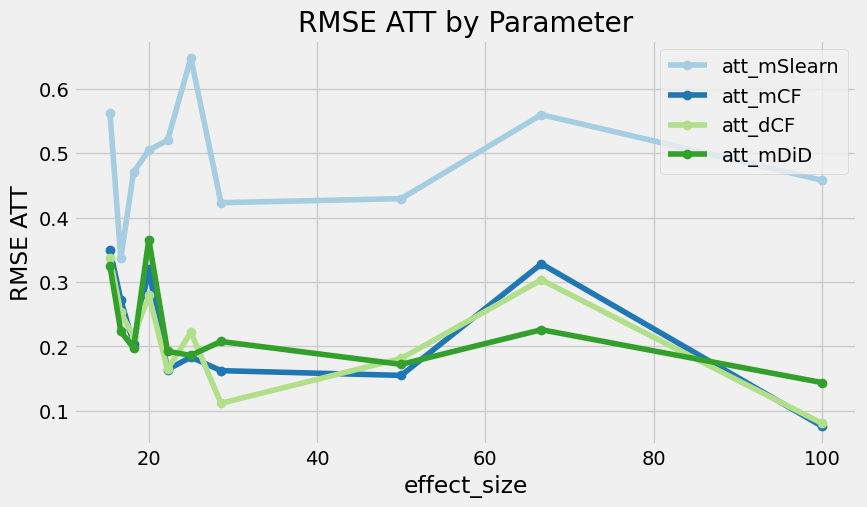

In [64]:
plot_rmse_att(
    df=df_results[df_results['ring'] == 'treated_inner_ring'],
    parameter_col="effect_size",
    att_true_col="true_effect",
    model_cols=["att_mSlearn", "att_mCF", 'att_dCF', 'att_mDiD']
)

C:\Users\andre\AppData\Local\Temp\ipykernel_12700\73641507.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


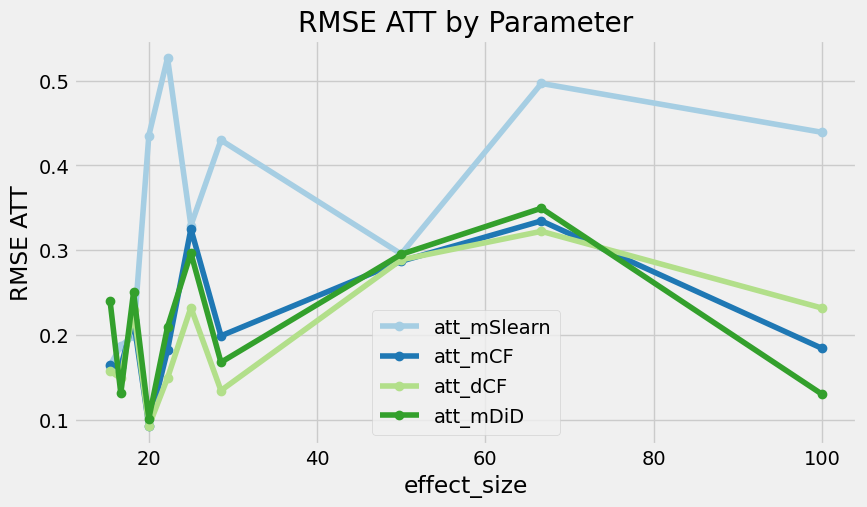

In [65]:
plot_rmse_att(
    df=df_results[df_results['ring'] == 'treated_outer_ring1'],
    parameter_col="effect_size",
    att_true_col="true_effect",
    model_cols=["att_mSlearn", "att_mCF", 'att_dCF', 'att_mDiD']
)

C:\Users\andre\AppData\Local\Temp\ipykernel_12700\73641507.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


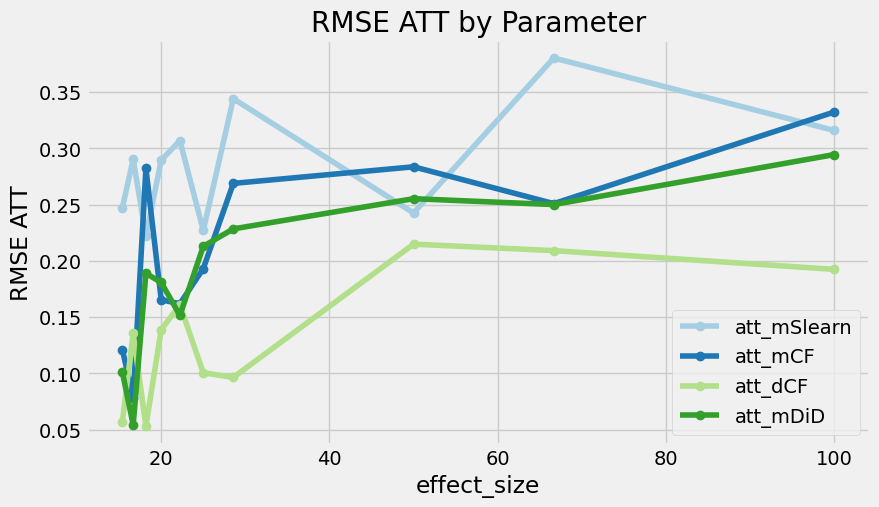

In [66]:
plot_rmse_att(
    df=df_results[df_results['ring'] == 'treated_outer_ring2'],
    parameter_col="effect_size",
    att_true_col="true_effect",
    model_cols=["att_mSlearn", "att_mCF", 'att_dCF', 'att_mDiD']
)

C:\Users\andre\AppData\Local\Temp\ipykernel_12700\73641507.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


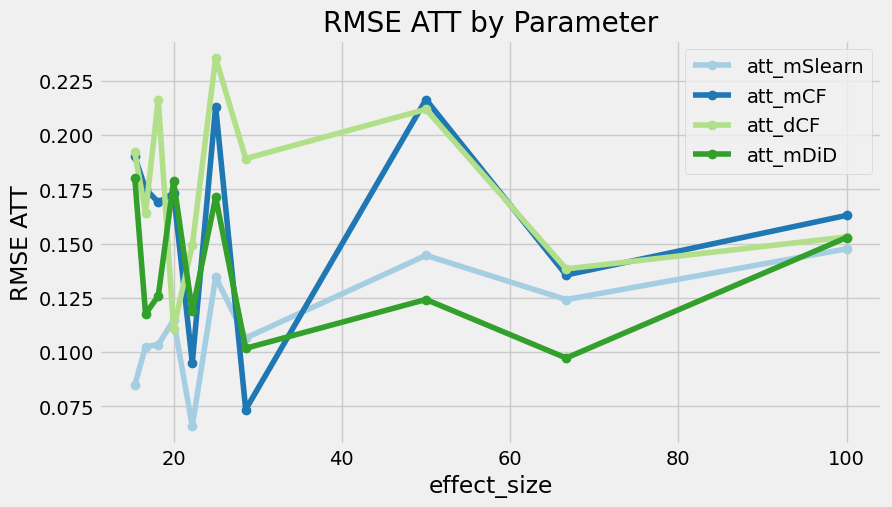

In [67]:
plot_rmse_att(
    df=df_results[df_results['ring'] == 'treated_outer_ring3'],
    parameter_col="effect_size",
    att_true_col="true_effect",
    model_cols=["att_mSlearn", "att_mCF", 'att_dCF', 'att_mDiD']
)

C:\Users\andre\AppData\Local\Temp\ipykernel_12700\73641507.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


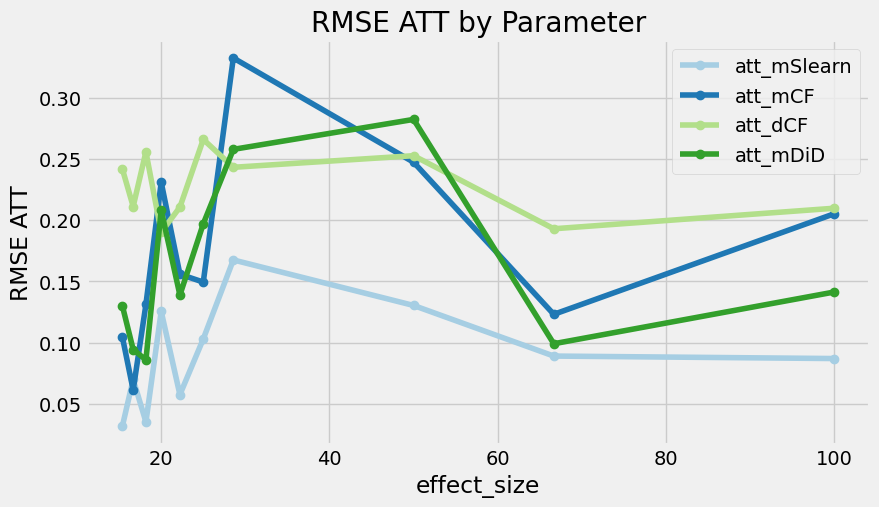

In [68]:
plot_rmse_att(
    df=df_results[df_results['ring'] == 'treated_outer_ring4'],
    parameter_col="effect_size",
    att_true_col="true_effect",
    model_cols=["att_mSlearn", "att_mCF", 'att_dCF', 'att_mDiD']
)

# Results visualization

In [75]:
cols_to_avg = [
    'true_effect',
    'att_mSlearn',
    'se_mSlearn',
    'att_mCF',
    'se_mCF',
    'att_dCF',
    'se_dCF',
    'att_mDiD',
    'se_mDiD'
]

result2 = (
    df_results.groupby(['effect_size', 'ring'])[cols_to_avg]
      .mean()
      .reset_index()
)
result2

,effect_size,ring,true_effect,att_mSlearn,se_mSlearn,att_mCF,se_mCF,att_dCF,se_dCF,att_mDiD,se_mDiD
0,15.384615,treated_inner_ring,1.500000,1.207976,0.149742,1.544071,0.063512,1.514155,0.064706,1.559569,0.235230
1,15.384615,treated_outer_ring1,0.885508,0.782034,0.125444,1.029023,0.079392,1.019647,0.077305,1.117031,0.228103
2,15.384615,treated_outer_ring2,0.522065,0.294355,0.075144,0.469498,0.048598,0.502661,0.037396,0.537393,0.205651
3,15.384615,treated_outer_ring3,0.154446,0.105812,0.038351,0.178410,0.035017,0.339974,0.018912,0.231477,0.177382
4,15.384615,treated_outer_ring4,0.021188,0.024360,0.038930,0.001489,0.028521,0.262207,0.011483,0.045042,0.168319
5,16.666667,treated_inner_ring,1.500000,1.339167,0.173376,1.559844,0.087740,1.540838,0.084081,1.573410,0.232306
6,16.666667,treated_outer_ring1,0.918212,0.746060,0.147184,0.927109,0.077899,0.935119,0.079953,0.975691,0.226221
7,16.666667,treated_outer_ring2,0.594777,0.333138,0.083744,0.566956,0.057412,0.479019,0.038863,0.626713,0.203815
8,16.666667,treated_outer_ring3,0.144663,0.051618,0.033665,0.225471,0.033145,0.303664,0.022021,0.172522,0.175206
9,16.666667,treated_outer_ring4,0.019167,0.048402,0.037908,0.069235,0.033334,0.228048,0.014267,0.074926,0.165384


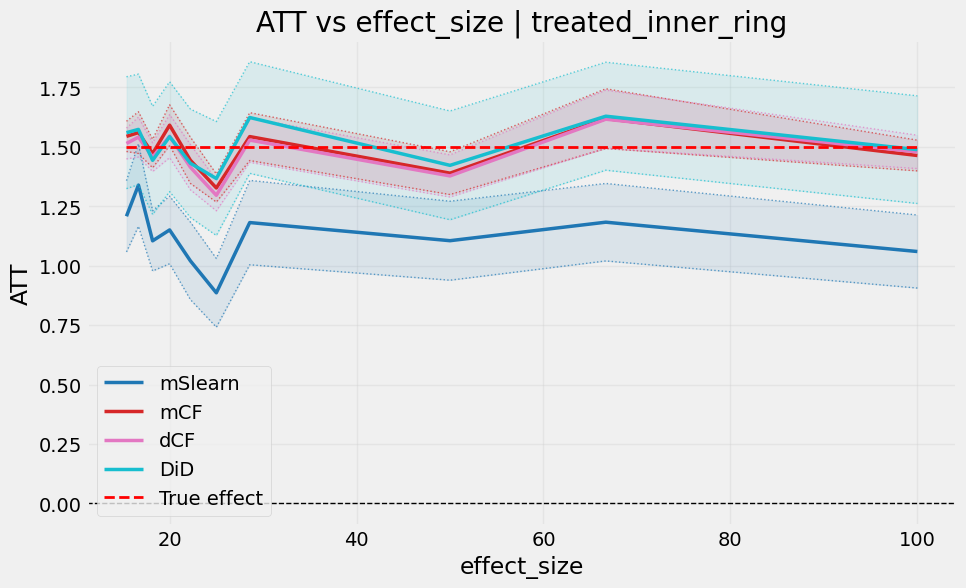

In [76]:
models = {
    "mSlearn": ("att_mSlearn", "se_mSlearn"),
    "mCF": ("att_mCF", "se_mCF"),
    'dCF' : ('att_dCF', 'se_dCF'),
    "DiD": ("att_mDiD", "se_mDiD")
}

plot_att_by_param(
    result2,
    param_col="effect_size",
    ring_value="treated_inner_ring",
    models_dict=models
)

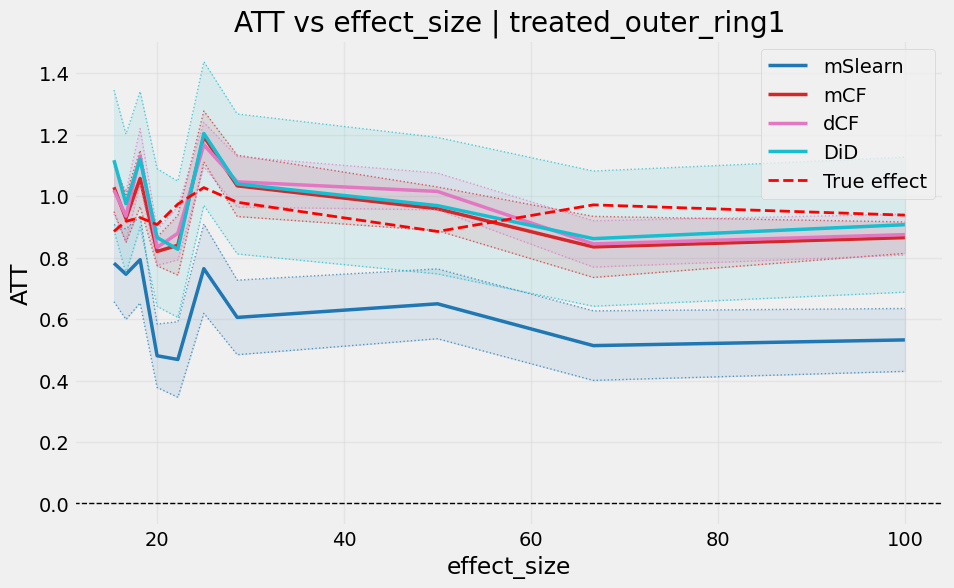

In [79]:
plot_att_by_param(
    result2,
    param_col="effect_size",
    ring_value="treated_outer_ring1",
    models_dict=models
)

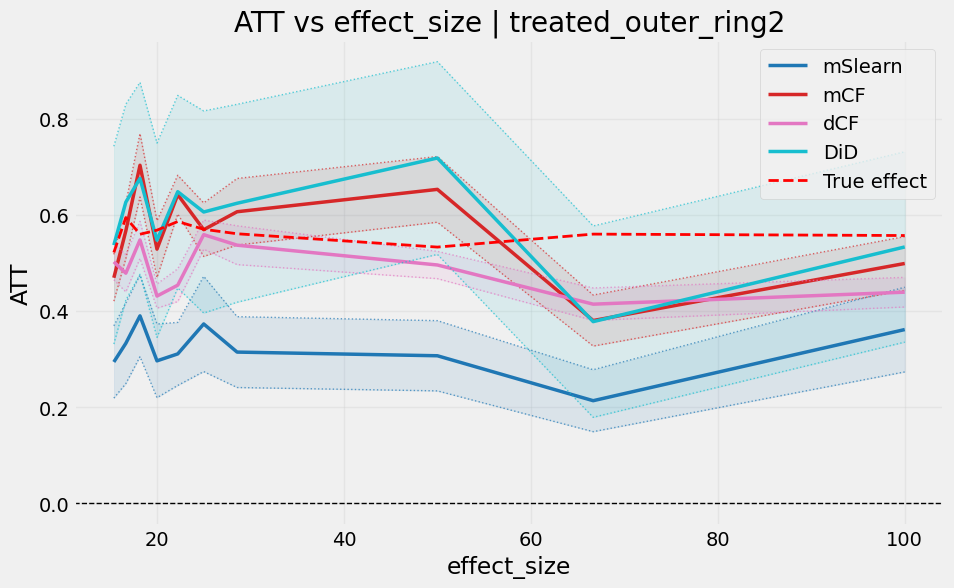

In [80]:
plot_att_by_param(
    result2,
    param_col="effect_size",
    ring_value="treated_outer_ring2",
    models_dict=models
)

In [95]:
df_results.reset_index()[df_results.reset_index()['index'].isin([3])].head(10)

,index,effect_size,ring,true_effect,att_mSlearn,se_mSlearn,att_mCF,se_mCF,att_dCF,se_dCF,att_mDiD,se_mDiD
3,3,100.000000,treated_outer_ring3,0.167426,0.048187,0.034964,0.065525,0.051165,0.384573,0.020059,0.114830,0.172673
8,3,66.666667,treated_outer_ring3,0.151402,-0.038427,0.044162,-0.072898,0.027296,0.238432,0.015620,0.069636,0.168169
13,3,50.000000,treated_outer_ring3,0.174752,0.018653,0.022535,-0.020872,0.021714,0.459836,0.016059,0.048897,0.183276
18,3,28.571429,treated_outer_ring3,0.156124,0.120789,0.028021,0.126594,0.025983,0.322242,0.008819,0.313263,0.173181
23,3,25.000000,treated_outer_ring3,0.144646,-0.082580,0.044818,-0.142465,0.052270,0.411404,0.016503,-0.108141,0.184071
28,3,22.222222,treated_outer_ring3,0.172341,0.073736,0.046879,0.266841,0.025832,0.319635,0.015435,0.296590,0.174398
33,3,20.000000,treated_outer_ring3,0.189385,0.013717,0.028514,0.049892,0.028732,0.305799,0.012358,0.080785,0.174973
38,3,18.181818,treated_outer_ring3,0.153910,0.029798,0.057097,-0.107121,0.039520,0.429906,0.030286,0.018662,0.179371
43,3,16.666667,treated_outer_ring3,0.141388,-0.000424,0.041150,0.121851,0.038458,0.230649,0.024377,0.137720,0.170729
48,3,15.384615,treated_outer_ring3,0.147826,-0.016768,0.030508,-0.139581,0.027081,0.400062,0.031517,-0.010385,0.177975


In [89]:
df_results#[df_results['effect_size'] == 100]

,effect_size,ring,true_effect,att_mSlearn,se_mSlearn,att_mCF,se_mCF,att_dCF,se_dCF,att_mDiD,se_mDiD
0,100.000000,treated_inner_ring,1.500000,0.926616,0.128377,1.355658,0.029126,1.366470,0.038531,1.269320,0.230196
1,100.000000,treated_outer_ring1,0.874312,0.633912,0.131296,0.986413,0.028414,1.086270,0.079665,0.968957,0.222772
2,100.000000,treated_outer_ring2,0.535993,0.667398,0.128674,0.883675,0.084699,0.604969,0.042810,0.865308,0.200264
3,100.000000,treated_outer_ring3,0.167426,0.048187,0.034964,0.065525,0.051165,0.384573,0.020059,0.114830,0.172673
4,100.000000,treated_outer_ring4,0.018586,-0.098569,0.042052,-0.297918,0.034072,0.292366,0.014754,-0.180025,0.163480
...,...,...,...,...,...,...,...,...,...,...,...
0,15.384615,treated_inner_ring,1.500000,0.678354,0.122450,1.072669,0.032784,1.052479,0.041748,1.151052,0.229977
1,15.384615,treated_outer_ring1,0.838837,0.859081,0.104649,0.949494,0.063160,0.846251,0.064278,1.145411,0.223197
2,15.384615,treated_outer_ring2,0.469257,0.090809,0.045879,0.285957,0.046709,0.426103,0.034286,0.321450,0.201202
3,15.384615,treated_outer_ring3,0.155644,0.116036,0.035120,0.221020,0.033540,0.295046,0.017374,0.174187,0.173328


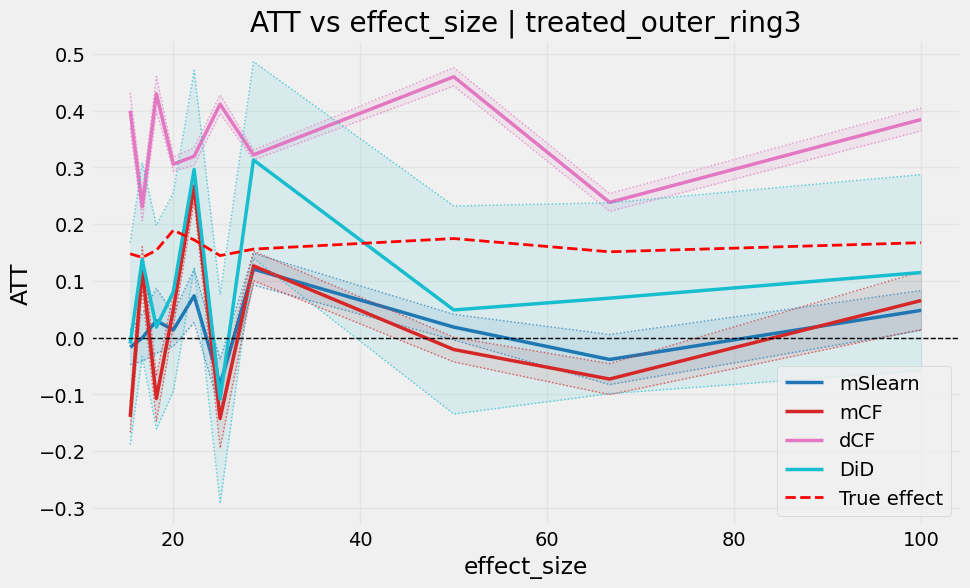

In [96]:
plot_att_by_param(
    df_results.reset_index()[df_results.reset_index()['index'].isin([3])].head(10),
    param_col="effect_size",
    ring_value="treated_outer_ring3",
    models_dict=models
)

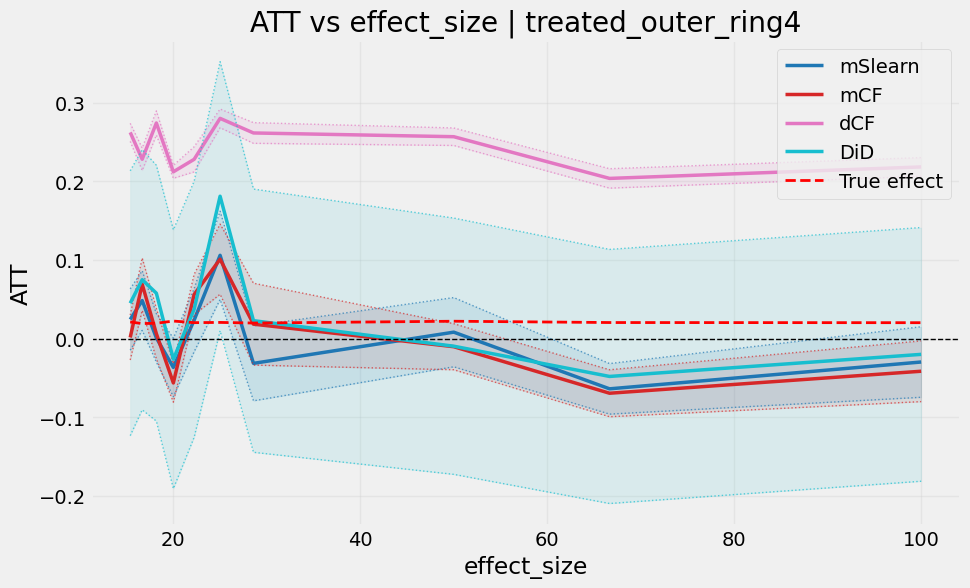

In [83]:
plot_att_by_param(
    result2,
    param_col="effect_size",
    ring_value="treated_outer_ring4",
    models_dict=models
)